In [1]:
%load_ext autoreload
%autoreload 2
import tensorflow as tf
import numpy as np
import gymnasium as gym

import jlab_opt_control.envs as custom_gym
import jlab_opt_control.agents as agents

import logging
run_openai_log = logging.getLogger("RunOpenAI")
run_openai_log.setLevel(logging.INFO)
logging.basicConfig(format='%(asctime)s %(levelname)s:%(name)s:%(message)s')

In [2]:
 # Environment
env_id = 'DnC2s-Circle2D-Stateless-v0'
run_openai_log.info('Running env: {}'.format(env_id))

if env_id in gym.envs.registry:
    env = gym.make(env_id)
elif env_id in custom_gym.list_registered_modules():
    env = custom_gym.make(env_id)

num_states = env.observation_space.shape[0]
run_openai_log.info("Size of State Space ->  {}".format(num_states))
num_actions = env.action_space.shape[0]
run_openai_log.info("Size of Action Space ->  {}".format(num_actions))

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

run_openai_log.info("Max Value of Action ->  {}".format(upper_bound))
run_openai_log.info("Min Value of Action ->  {}".format(lower_bound))

2024-06-10 11:48:09,346 INFO:RunOpenAI:Running env: DnC2s-Circle2D-Stateless-v0
2024-06-10 11:48:09,346 INFO:Circle2D-Env:############# Init Circle2D #############
2024-06-10 11:48:09,347 INFO:Circle2D-Env:Statefull: False
2024-06-10 11:48:09,347 INFO:Circle2D-Env:RDM Reset Mode: fixed
2024-06-10 11:48:09,348 INFO:Circle2D-Env:Action upper bound: [1. 1.]
2024-06-10 11:48:09,348 INFO:Circle2D-Env:Action lower bound: [-1. -1.]
2024-06-10 11:48:09,349 INFO:Circle2D-Env:State upper bound: [1. 1.]
2024-06-10 11:48:09,349 INFO:Circle2D-Env:State lower bound: [-1. -1.]
2024-06-10 11:48:09,349 INFO:Circle2D-Env:Target value: 0.95
2024-06-10 11:48:09,350 INFO:Circle2D-Env:Max episode steps: 1
2024-06-10 11:48:09,350 INFO:RunOpenAI:Size of State Space ->  2
2024-06-10 11:48:09,350 INFO:RunOpenAI:Size of Action Space ->  2
2024-06-10 11:48:09,350 INFO:RunOpenAI:Max Value of Action ->  1.0
2024-06-10 11:48:09,351 INFO:RunOpenAI:Min Value of Action ->  -1.0


{'DnC2s-Circle2D-Statefull-v0': <jlab_opt_control.envs.registration.EnvSpec object at 0x36c5c4520>, 'DnC2s-Circle2D-Stateless-v0': <jlab_opt_control.envs.registration.EnvSpec object at 0x111cfb700>}
Attempting to load jlab_opt_control.envs with Circle2D


In [3]:
import os
import jlab_opt_control.agents as agents

logging.getLogger("Agent Registry").setLevel(logging.INFO)
logging.getLogger("TD3-Agent").setLevel(logging.INFO)

# Agent
agent_id = 'KerasTD3-v0'
logdir = './results/Circle/index0_agent_KerasTD3-v0_env_DnC2s-Circle2D-Stateless-v0_date_20240530-170515'

os.makedirs(logdir, exist_ok=True)
buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

agent.model_load_path = f'{logdir}/models/epoch_12799_005/'
agent.load()

2024-06-10 11:48:09,379 INFO:Agent Registry:Making new agent: KerasTD3-v0 ({'env': <jlab_opt_control.envs.circle_env.Circle2D object at 0x36f5fc970>, 'logdir': './results/Circle/index0_agent_KerasTD3-v0_env_DnC2s-Circle2D-Stateless-v0_date_20240530-170515', 'buffer_type': 'ER-v0', 'buffer_size': None})
2024-06-10 11:48:09,380 INFO:TD3-Agent:Running KerasTD3 __init__
2024-06-10 11:48:09,381 INFO:TD3-Agent:Action upper bound: [1. 1.]
2024-06-10 11:48:09,381 INFO:TD3-Agent:Action upper bound: 1.0
2024-06-10 11:48:09,381 INFO:TD3-Agent:Action lower bound: [-1. -1.]
2024-06-10 11:48:09,381 INFO:TD3-Agent:Action lower bound: -1.0
2024-06-10 11:48:09,382 INFO:TD3-Agent:Action range: [2. 2.]
2024-06-10 11:48:09,382 ERROR:CfgLogger:Problem with key request using None
2024-06-10 11:48:09,385 INFO:Buffer:Buffer config saved successfully
2024-06-10 11:48:09,386 INFO:TD3-Agent:Using legacy Adam
2024-06-10 11:48:09,388 INFO:TD3-Agent:Running KerasTD3 initialize_new_models()
2024-06-10 11:48:09,408 E

Attempting to load jlab_opt_control.agents with KerasTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN


2024-06-10 11:48:09,559 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.
2024-06-10 11:48:09,562 ERROR:Critic:Number of activation functions (+1 for output layer) does not match the number of hidden layers in the config.


Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN


2024-06-10 11:48:09,587 ERROR:CfgLogger:Problem with key request using 2
2024-06-10 11:48:09,587 ERROR:CfgLogger:Problem with key request using 2
2024-06-10 11:48:09,587 WARNING:TD3-Agent:[Errno 17] File exists: './results/Circle/index0_agent_KerasTD3-v0_env_DnC2s-Circle2D-Stateless-v0_date_20240530-170515'
2024-06-10 11:48:09,608 INFO:TD3-Agent:Models loaded successfully


(50, 50) (50, 50) (2500, 1) (2500, 2)
(2500, 2)


Text(0.5, 0.98, 'TD3 Agent')

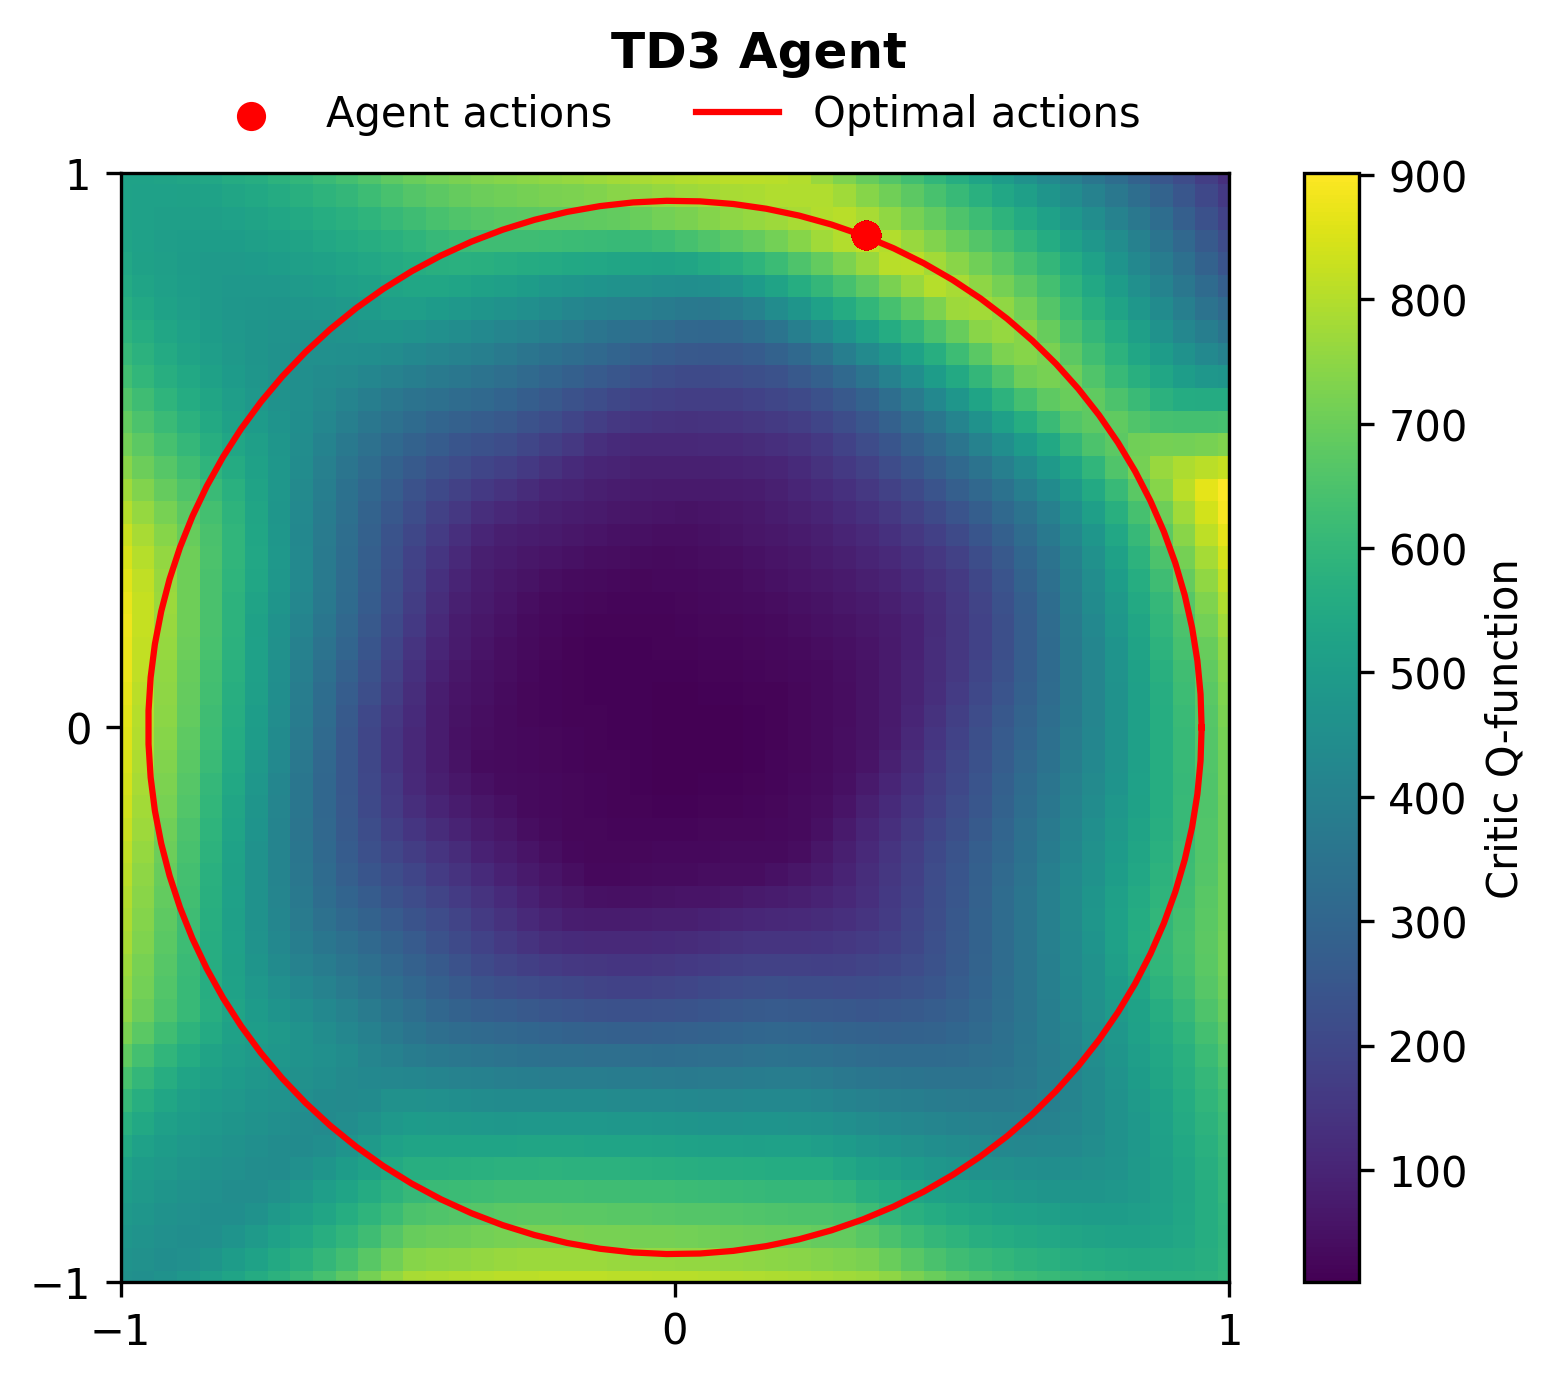

In [4]:
x = np.linspace(env.action_space.low[0], env.action_space.high[0])
y = np.linspace(env.action_space.low[1], env.action_space.high[1])

X, Y = np.meshgrid(x, y)
actions = np.stack([X, Y]).reshape(2, -1).T
states = np.zeros_like(actions)

critic_values = agent.critic_model1(states, actions, training=False).numpy()
actor_values = agent.actor_model(states, training=False)

print(X.shape, Y.shape, critic_values.shape, actor_values.shape)

# Plot action distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, dpi=300)
im = ax.pcolormesh(X, Y, critic_values.reshape(X.shape), cmap='viridis')
ax.scatter(actor_values[:, 0], actor_values[:, 1], color='red', 
           label='Agent actions', zorder=10)

t = np.linspace(0, 2*np.pi, 100)
ax.plot(0.95*np.cos(t), 0.95*np.sin(t), color='red', 
        label='Optimal actions')

ax.set(xlim=[-1, 1], ylim=[-1, 1], 
       xticks=[-1, 0, 1], yticks=[-1, 0, 1],
       aspect='equal')
plt.colorbar(im, ax=ax, label='Critic Q-function')
ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
          ncol=2, framealpha=0)
print(actor_values.shape)

fig.suptitle('TD3 Agent', fontweight='bold')

(2500, 2) (2500, 1)
Q = -46.845 1 + 893.254 a0^2 + 963.147 a1^2 + -13.331 a0^4 + -1423.685 a0^2 a1^2 + -79.314 a1^4
R2 score is 0.929


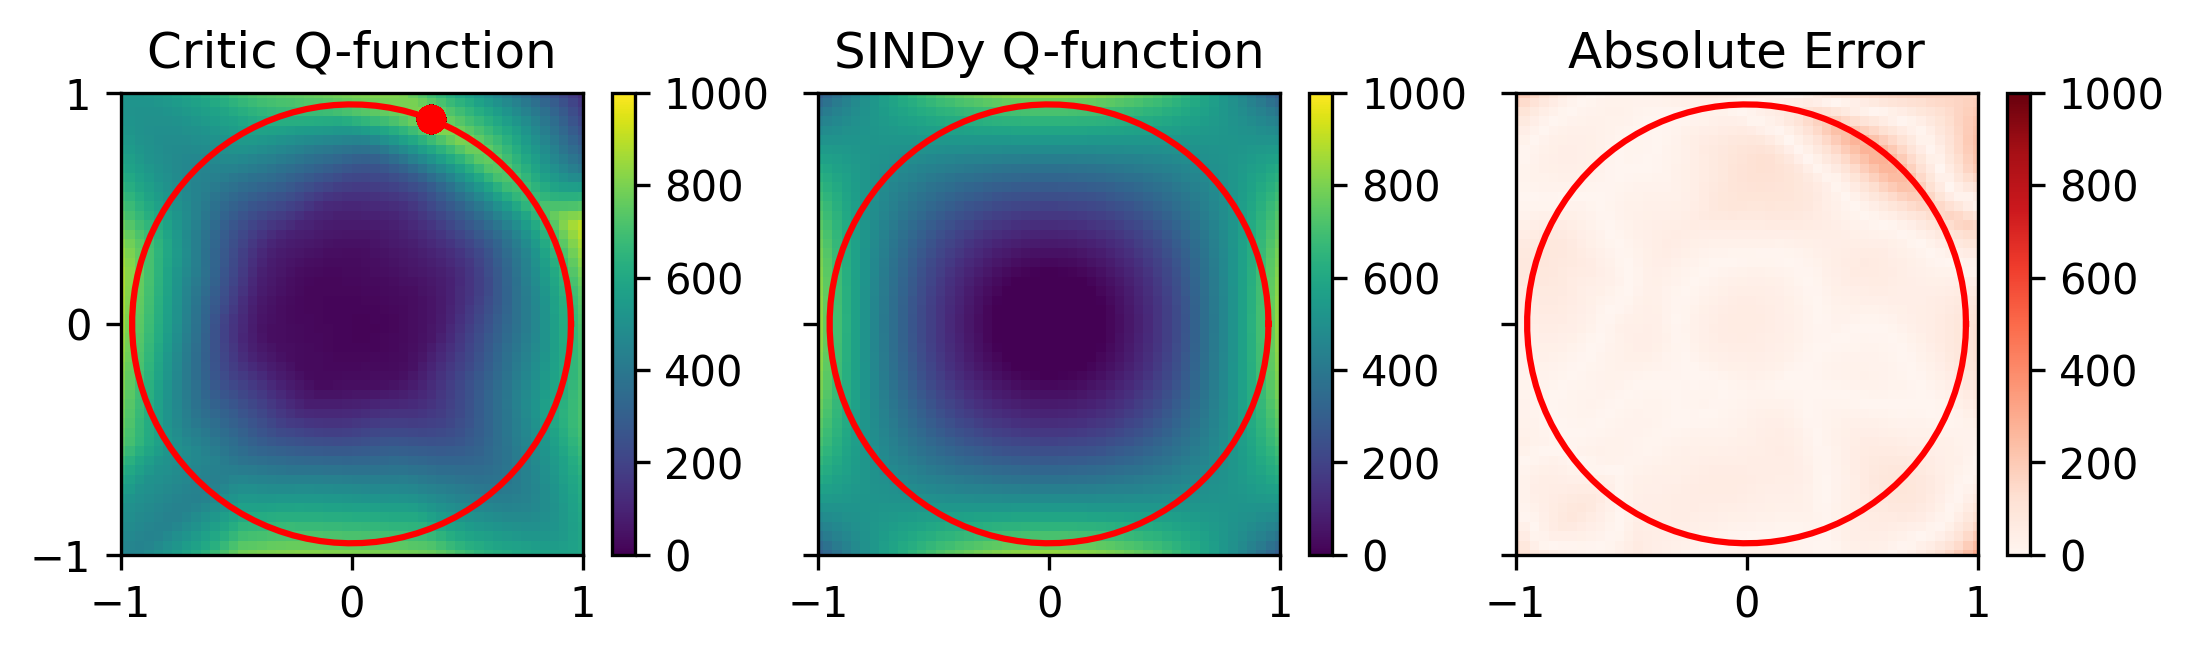

In [5]:
import pysindy as ps

inputs = np.concatenate([states, actions], axis=1)[:, 2:]
targets = critic_values.reshape([-1, 1])
print(inputs.shape, targets.shape)

sindy = ps.SINDy(
    feature_library=ps.PolynomialLibrary(degree=4),
    #feature_library=ps.FourierLibrary(n_frequencies=4),
    optimizer=ps.STLSQ(threshold=10, alpha=1e3, normalize_columns=True),
    feature_names=['a0', 'a1']
)
sindy.fit(x=inputs, x_dot=targets)
sindy.print(lhs='Q')
sindy_values = sindy.predict(inputs)

print(f'R2 score is {sindy.score(x=inputs, x_dot=targets):.3f}')

# Plot action distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(8.5, 2), dpi=300, sharex=True, sharey=True)
im = ax[0].pcolormesh(X, Y, critic_values.reshape(X.shape), cmap='viridis', vmin=0, vmax=1e3)
plt.colorbar(im, ax=ax[0])
ax[0].scatter(actor_values[:, 0], actor_values[:, 1], color='red', 
           label='Agent actions', zorder=10)
ax[0].set_title("Critic Q-function")

im = ax[1].pcolormesh(X, Y, sindy_values.reshape(X.shape), cmap='viridis', vmin=0, vmax=1e3)
plt.colorbar(im, ax=ax[1])
ax[1].set_title('SINDy Q-function')

im = ax[2].pcolormesh(X, Y, np.abs(critic_values - sindy_values).reshape(X.shape), cmap='Reds', vmin=0, vmax=1e3)
plt.colorbar(im, ax=ax[2])
ax[2].set_title('Absolute Error')

t = np.linspace(0, 2*np.pi, 100)
for a in ax:
    a.plot(0.95*np.cos(t), 0.95*np.sin(t), color='red', 
           label='Optimal actions')

    a.set(xlim=[-1, 1], ylim=[-1, 1], 
          xticks=[-1, 0, 1], yticks=[-1, 0, 1],
          aspect='equal')

2024-06-10 11:48:21,575 INFO:Agent Registry:Making new agent: KerasSINDyCriticTD3-v0 ({'env': <jlab_opt_control.envs.circle_env.Circle2D object at 0x36f5fc970>, 'logdir': './results/Circle/index0_agent_KerasSINDyCriticTD3-v0_env_DnC2s-Circle2D-Stateless-v0_date_20240531-110005', 'buffer_type': 'ER-v0', 'buffer_size': None})
2024-06-10 11:48:21,576 INFO:TD3-Agent:Running KerasTD3 __init__
2024-06-10 11:48:21,576 INFO:TD3-Agent:Action upper bound: [1. 1.]
2024-06-10 11:48:21,577 INFO:TD3-Agent:Action upper bound: 1.0
2024-06-10 11:48:21,577 INFO:TD3-Agent:Action lower bound: [-1. -1.]
2024-06-10 11:48:21,577 INFO:TD3-Agent:Action lower bound: -1.0
2024-06-10 11:48:21,578 INFO:TD3-Agent:Action range: [2. 2.]
2024-06-10 11:48:21,579 ERROR:CfgLogger:Problem with key request using None
2024-06-10 11:48:21,579 ERROR:CfgLogger:Problem with key request using 200
2024-06-10 11:48:21,583 INFO:Buffer:Buffer config saved successfully
2024-06-10 11:48:21,583 INFO:TD3-Agent:Using legacy Adam
2024-06-

Attempting to load jlab_opt_control.agents with KerasSINDyCriticTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with SINDyNetwork
Attempting to load jlab_opt_control.models with SINDyNetwork


2024-06-10 11:48:22,141 ERROR:CfgLogger:Problem with key request using 2
2024-06-10 11:48:22,142 ERROR:CfgLogger:Problem with key request using 2
2024-06-10 11:48:22,142 WARNING:TD3-Agent:[Errno 17] File exists: './results/Circle/index0_agent_KerasSINDyCriticTD3-v0_env_DnC2s-Circle2D-Stateless-v0_date_20240531-110005'
2024-06-10 11:48:22,158 INFO:TD3-Agent:Models loaded successfully


Attempting to load jlab_opt_control.models with SINDyNetwork
Attempting to load jlab_opt_control.models with SINDyNetwork


Text(0.5, 0.98, 'SINDy-TD3 Agent')

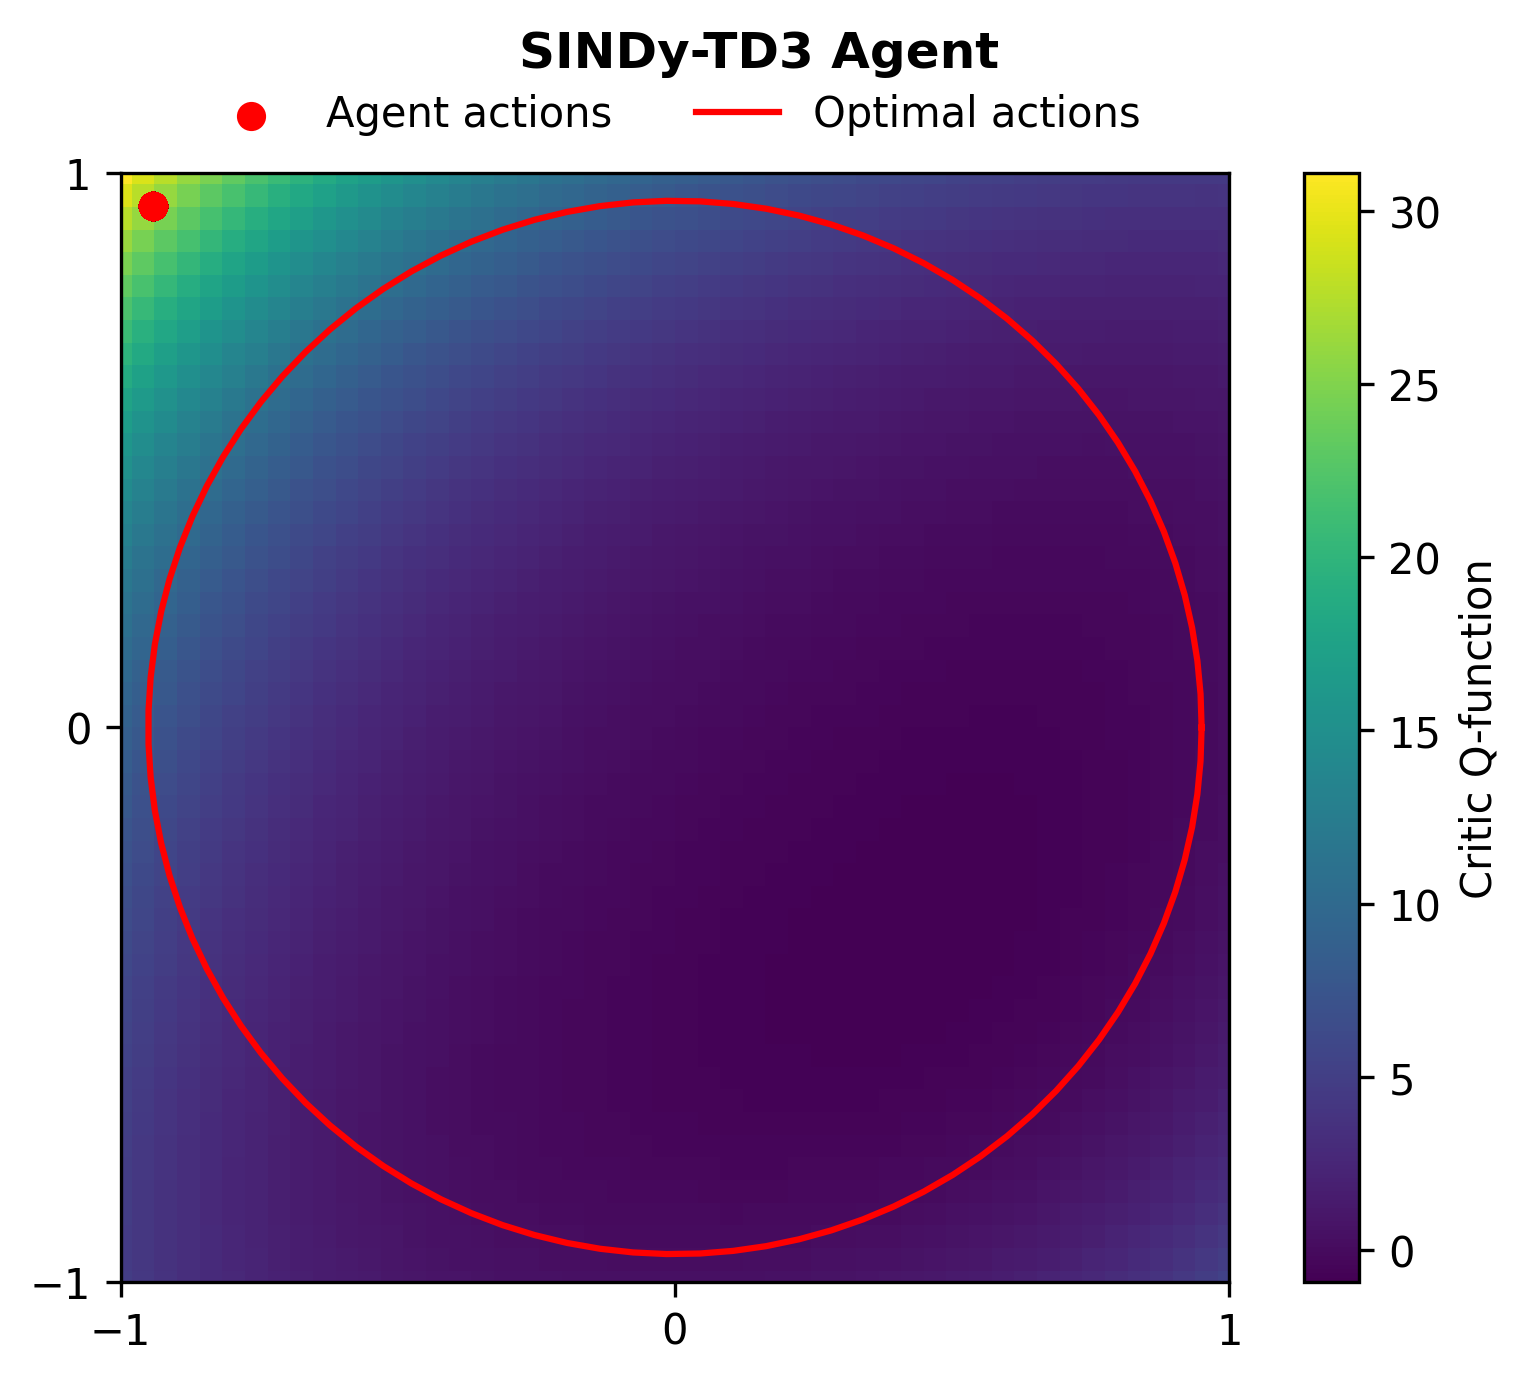

In [6]:
import os
import jlab_opt_control.agents as agents

logging.getLogger("Agent Registry").setLevel(logging.INFO)
logging.getLogger("TD3-Agent").setLevel(logging.INFO)

# Agent
agent_id = 'KerasSINDyCriticTD3-v0'
logdir = './results/Circle/index0_agent_KerasSINDyCriticTD3-v0_env_DnC2s-Circle2D-Stateless-v0_date_20240531-110005'

os.makedirs(logdir, exist_ok=True)
buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

agent.model_load_path = f'{logdir}/models/epoch_9999/'
agent.load()

x = np.linspace(env.action_space.low[0], env.action_space.high[0])
y = np.linspace(env.action_space.low[1], env.action_space.high[1])

X, Y = np.meshgrid(x, y)
actions = np.stack([X, Y]).reshape(2, -1).T
states = np.zeros_like(actions)

states_actions = tf.keras.layers.Concatenate(axis=1)([states, actions])
lib_batch = agent.library(states_actions)
critic_values = agent.critic_model1(lib_batch).numpy()
actor_values = agent.actor_model(states, training=False)

# Plot action distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, dpi=300)
im = ax.pcolormesh(X, Y, critic_values.reshape(X.shape), cmap='viridis')
ax.scatter(actor_values[:, 0], actor_values[:, 1], color='red', 
           label='Agent actions', zorder=10)

t = np.linspace(0, 2*np.pi, 100)
ax.plot(0.95*np.cos(t), 0.95*np.sin(t), color='red', 
        label='Optimal actions')

ax.set(xlim=[-1, 1], ylim=[-1, 1], 
       xticks=[-1, 0, 1], yticks=[-1, 0, 1],
       aspect='equal')
plt.colorbar(im, ax=ax, label='Critic Q-function')
ax.legend(loc='lower center', bbox_to_anchor=[0.5, 1],
          ncol=2, framealpha=0)

fig.suptitle('SINDy-TD3 Agent', fontweight='bold')

2024-06-10 11:54:26,107 INFO:Agent Registry:Making new agent: KerasJointCriticTD3-v0 ({'env': <jlab_opt_control.envs.circle_env.Circle2D object at 0x36f5fc970>, 'logdir': './results/Circle/index0_agent_KerasJointCriticTD3-v0_env_DnC2s-Circle2D-Stateless-v0_date_20240531-113828', 'buffer_type': 'ER-v0', 'buffer_size': None})
2024-06-10 11:54:26,107 INFO:TD3-Agent:Running KerasTD3 __init__
2024-06-10 11:54:26,108 INFO:TD3-Agent:Action upper bound: [1. 1.]
2024-06-10 11:54:26,108 INFO:TD3-Agent:Action upper bound: 1.0
2024-06-10 11:54:26,109 INFO:TD3-Agent:Action lower bound: [-1. -1.]
2024-06-10 11:54:26,109 INFO:TD3-Agent:Action lower bound: -1.0
2024-06-10 11:54:26,109 INFO:TD3-Agent:Action range: [2. 2.]
2024-06-10 11:54:26,110 ERROR:CfgLogger:Problem with key request using None
2024-06-10 11:54:26,110 ERROR:CfgLogger:Problem with key request using 200
2024-06-10 11:54:26,113 INFO:Buffer:Buffer config saved successfully
2024-06-10 11:54:26,114 INFO:TD3-Agent:Using legacy Adam
2024-06-

Attempting to load jlab_opt_control.agents with KerasJointCriticTD3
Attempting to load jlab_opt_control.buffers with ER
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with ActorFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with CriticFCNN
Attempting to load jlab_opt_control.models with SINDyNetwork
Attempting to load jlab_opt_control.models with SINDyNetwork


2024-06-10 11:54:26,815 ERROR:CfgLogger:Problem with key request using 2
2024-06-10 11:54:26,816 ERROR:CfgLogger:Problem with key request using 2
2024-06-10 11:54:26,816 WARNING:TD3-Agent:[Errno 17] File exists: './results/Circle/index0_agent_KerasJointCriticTD3-v0_env_DnC2s-Circle2D-Stateless-v0_date_20240531-113828'
2024-06-10 11:54:26,831 INFO:TD3-Agent:Models loaded successfully


Attempting to load jlab_opt_control.models with SINDyNetwork
Attempting to load jlab_opt_control.models with SINDyNetwork


Text(0.5, 0.98, 'Joint TD3 Agent')

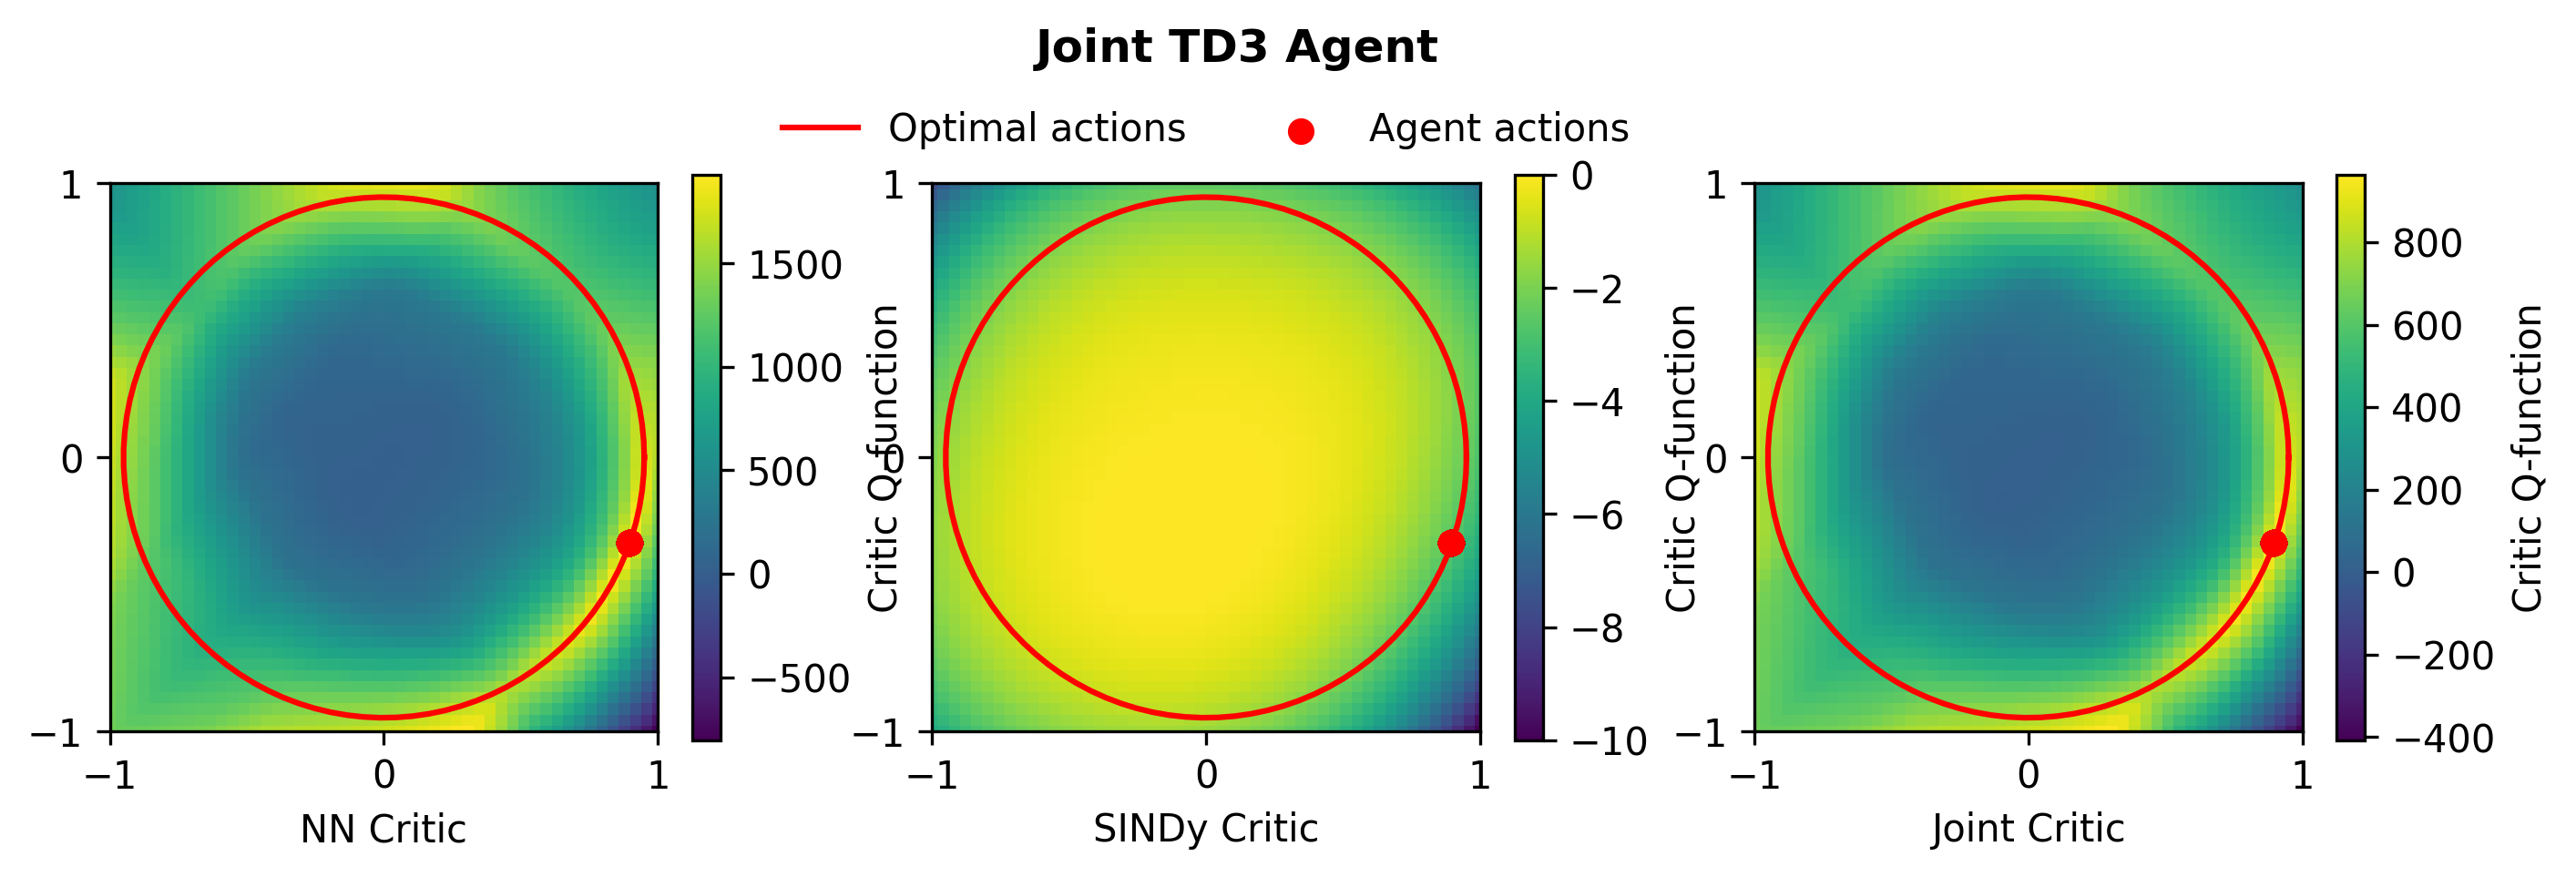

In [22]:
import os
import glob
import jlab_opt_control.agents as agents

logging.getLogger("Agent Registry").setLevel(logging.INFO)
logging.getLogger("TD3-Agent").setLevel(logging.INFO)

# Agent
agent_id = 'KerasJointCriticTD3-v0'
logdir = glob.glob(f'./results/Circle/index0_agent_{agent_id}_env_{env_id}_date_20240531-*')[0]

buffer_type = 'ER-v0'
buffer_size = None

agent = agents.make(
    agent_id, 
    env=env, 
    logdir=logdir, 
    buffer_type=buffer_type, 
    buffer_size=buffer_size,
)

agent.model_load_path = f'{logdir}/models/epoch_19999/'
agent.load()

x = np.linspace(env.action_space.low[0], env.action_space.high[0])
y = np.linspace(env.action_space.low[1], env.action_space.high[1])

X, Y = np.meshgrid(x, y)
actions = np.stack([X, Y]).reshape(2, -1).T
states = np.zeros_like(actions)

states_actions = tf.keras.layers.Concatenate(axis=1)([states, actions])
lib_batch = agent.library(states_actions)
actor_values = agent.actor_model(states, training=False)

# Plot action distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, dpi=300, figsize=(11, 3))

critic_values = agent.critic_model1(states, actions).numpy()
im = ax[0].pcolormesh(X, Y, critic_values.reshape(X.shape), 
                      cmap='viridis')#, vmin=-10, vmax=0)
plt.colorbar(im, ax=ax[0], label='Critic Q-function')


critic_values = agent.critic_sindy1(lib_batch).numpy()
im = ax[1].pcolormesh(X, Y, critic_values.reshape(X.shape), 
                      cmap='viridis', vmin=-10, vmax=0)
plt.colorbar(im, ax=ax[1], label='Critic Q-function')


critic_values = (1 - agent.sindy_beta) * agent.critic_model1(states, actions).numpy() + \
                agent.sindy_beta * agent.critic_sindy1(lib_batch).numpy()
im = ax[2].pcolormesh(X, Y, critic_values.reshape(X.shape), 
                      cmap='viridis')#, vmin=-10, vmax=0)
plt.colorbar(im, ax=ax[2], label='Critic Q-function')


for a in ax:
    t = np.linspace(0, 2*np.pi, 100)
    a.plot(0.95*np.cos(t), 0.95*np.sin(t), color='red', 
            label='Optimal actions')
    a.scatter(actor_values[:, 0], actor_values[:, 1], color='red',
              label='Agent actions', zorder=10)

    a.set(xlim=[-1, 1], ylim=[-1, 1], 
        xticks=[-1, 0, 1], yticks=[-1, 0, 1],
        aspect='equal')
ax[1].legend(loc='lower center', bbox_to_anchor=[0.5, 1],
        ncol=2, framealpha=0)
    
ax[0].set_xlabel('NN Critic')
ax[1].set_xlabel('SINDy Critic')
ax[2].set_xlabel('Joint Critic')

fig.subplots_adjust(top=0.8)
fig.suptitle('Joint TD3 Agent', fontweight='bold')